In [1]:
import pandas as pd
df = pd.read_csv("../data/examples_DBAASP/descriptors_positive_staphylococcus.csv")

In [2]:
# normalizing the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

In [3]:
# variance treshold - remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(df_feat)
df_feat = df_feat[df_feat.columns[selector.get_support(indices=True)]]

print(f"Features dropped: {df.columns[~selector.get_support()]}")
print(f"New shape: {df_feat.shape}")

Features dropped: Index([], dtype='object')
New shape: (721, 102)


In [4]:
# trash randomly one of the features with correlation > 0.85
import numpy as np
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")

Features dropped: ['F2', 'F3', 'KF1', 'KF2', 'MSWHIM1', 'E1', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'ProtFP1', 'ProtFP2', 'SV2', 'ST1', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T4', 'VHSE1', 'VHSE2', 'VHSE3', 'VSTPV1', 'VSTPV3', 'Z1', 'Z2']
New shape: (721, 76)


In [5]:
# trash all features with "BLOSUM" in the name
to_drop = [col for col in df_feat.columns if "BLOSUM" in col]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")

Features dropped: ['BLOSUM1', 'BLOSUM2', 'BLOSUM3', 'BLOSUM4', 'BLOSUM5', 'BLOSUM6', 'BLOSUM7', 'BLOSUM8', 'BLOSUM9', 'BLOSUM10']
New shape: (721, 66)


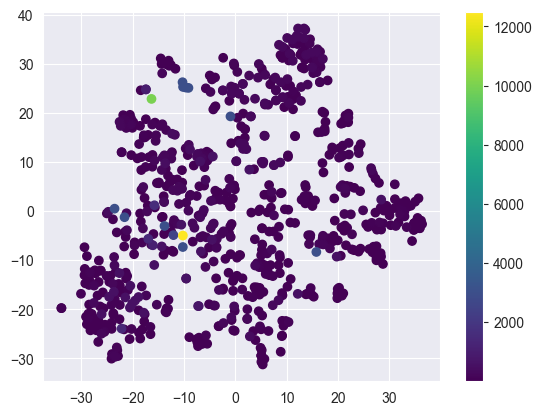

In [6]:
# TSNE for activity for all 700 data points
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

activities = pd.read_csv("../data/examples_DBAASP/positive_peptides_without_modifications.csv")
df_feat["activity"] = activities["ACTIVITY"]

# color gradient for activity
colors = df_feat["activity"]

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(df_feat.drop(columns=["activity"]))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=colors, cmap="viridis")
plt.colorbar()

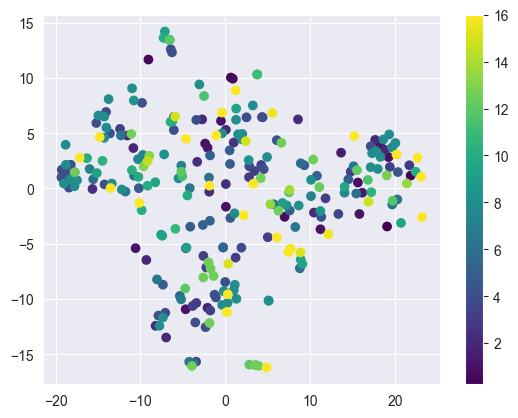

In [7]:
# TSNE for activity for 350 data points with low MIC

df_feat_dropped = df_feat.drop(df_feat.tail(450).index)
colors = df_feat_dropped["activity"]

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(df_feat_dropped.drop(columns=["activity"]))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=colors, cmap="viridis")
plt.colorbar()

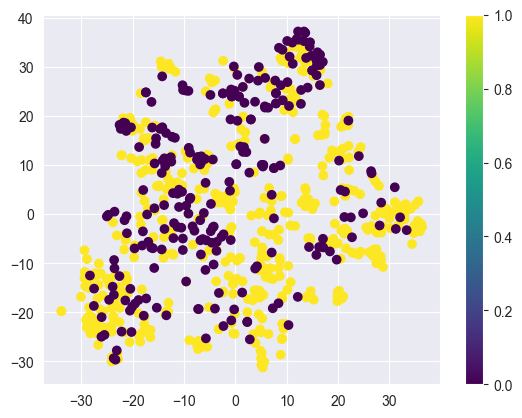

In [8]:
# distinguish between low and high activity and show TSNE
df_feat["activity"] = df_feat["activity"].apply(lambda x: 1 if x < 100 else 0)
colors = df_feat["activity"]

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(df_feat.drop(columns=["activity"]))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=colors, cmap="viridis")
plt.colorbar()